Create a new Python application

In [1]:
# Azure의 Custom Vision 라이브러리를 추가. 예측을 위하여 prediction을 포함
from azure.cognitiveservices.vision.customvision.prediction import CustomVisionPredictionClient
# OpenAPI 스펙에 맞춰서 Authentication을 처리할 수 있도록 해주는 코드
from msrest.authentication import ApiKeyCredentials
# Matplotlib의 pyplot을 포함하여 예측 결과를 그리기
from matplotlib import pyplot as plt
# Python Image 라이브러리로 이미지 그리기
from PIL import Image, ImageDraw, ImageFont
# Python Numpy (수학 및 과학 연산 패키지) 포함
import numpy as np
# 파일 처리 작업을 위해 os 라이브러리 포함
import os

Create variables for your resource's Azure endpoint and keys.

In [ ]:
# 사용자가 만든 AI 모델의 예측 기능을 사용하기 위한 endpoint 지정
prediction_endpoint = ""
prediction_key = ""
# 프로젝트 ID 지정
project_id = ""
# 모델명 지정
model_name = ""

Authenticate the client

In [14]:
# 앞에서 지정한 API KEY를 써서 커스텀 비전 모델을 사용할 클라이언트를 인증
credentials = ApiKeyCredentials(in_headers={"Prediction-key": prediction_key})
# endpoint를 써서 클라이언트 등록
predictor = CustomVisionPredictionClient(endpoint=prediction_endpoint, credentials=credentials)

Load image and get height, width and channels

In [15]:
# 테스트 이미지를 Codespace workspace에 추가한 후 image_file 변수로 지정
image_file = "./test-1.png"
# 이미지 파일 등록되었음을 출력
print("Detecting objects in ", image_file)
# Python Imaging Library의 image open함수를 써서 테스트 이미지 파일 오픈
image = Image.open(image_file)
# Numpy에서 이미지의 shape을 높이, 폭, 채널 읽기
h, w, ch = np.array(image).shape

Detecting objects in  ./test-1.png


Detect objects in the test image

Results saved in output.jpg


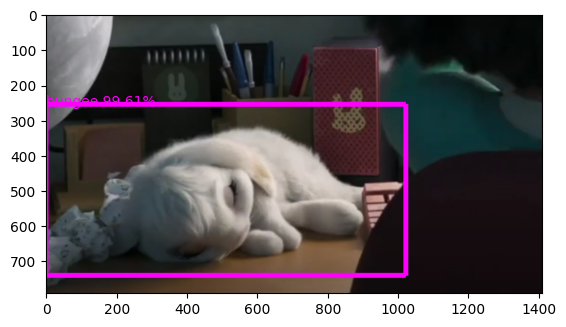

In [17]:
# 개체 인식된 모든 결과에 대해서
for prediction in results.predictions:

    # 확률이 50%이 이상인 경우 bounding box 값을 읽음
    if (prediction.probability * 100) > 50:
        left   = prediction.bounding_box.left   * w
        top    = prediction.bounding_box.top    * h
        width  = prediction.bounding_box.width  * w
        height = prediction.bounding_box.height * h

        # bounding box 값을 magenta색으로 표시
        points = ((left, top), (left + width, top), (left + width, top + height), (left, top + height), (left, top))
        draw.line(points, fill=color, width=lineWidth)
        plt.annotate(prediction.tag_name + ' {0:.2f}%'.format(prediction.probability * 100), (left, top), color=color)

# bounding box 표시된 이미지를 output.jpg로 저장
plt.imshow(image)
outputfile = 'output.jpg'
fig.savefig(outputfile)
print('Results saved in', outputfile)

	bungee: 99.61% bbox.left = 0.00, bbox.top = 0.32, bbox.width = 0.73, bbox.height = 0.61
	bungee: 18.43% bbox.left = 0.60, bbox.top = 0.09, bbox.width = 0.40, bbox.height = 0.91
	bungee: 17.02% bbox.left = 0.00, bbox.top = 0.01, bbox.width = 0.13, bbox.height = 0.55
	bungee: 3.59% bbox.left = 0.00, bbox.top = 0.10, bbox.width = 0.51, bbox.height = 0.90
	bungee: 1.24% bbox.left = 0.00, bbox.top = 0.44, bbox.width = 0.15, bbox.height = 0.56
	bungee: 1.17% bbox.left = 0.73, bbox.top = 0.90, bbox.width = 0.27, bbox.height = 0.10


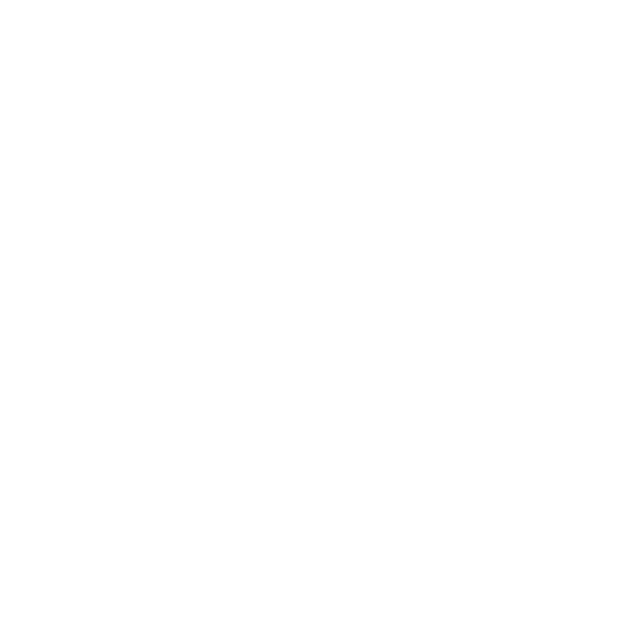

In [16]:
# 테스트 이미지를 열고 모델에 적용해서 결과를 저장
with open(image_file, mode="rb") as image_data:
    results = predictor.detect_image(project_id, model_name, image_data)

# 예측한 결과를 모두 출력 (텍스트로 표시됨)
for prediction in results.predictions:
    print("\t" + prediction.tag_name +
          ": {0:.2f}% bbox.left = {1:.2f}, bbox.top = {2:.2f}, bbox.width = {3:.2f}, bbox.height = {4:.2f}".format(
              prediction.probability * 100,
              prediction.bounding_box.left,
              prediction.bounding_box.top,
              prediction.bounding_box.width,
              prediction.bounding_box.height))

# 그래프 크기 지정하고 축 비활성화
fig = plt.figure(figsize=(8, 8))
plt.axis('off')

# 테스트 이미지를 그리기
# 개체 인식 박스를 magenta로 지정
draw = ImageDraw.Draw(image)
lineWidth = int(w / 100)
color = 'magenta'

Create a figure for the results
Display the image with boxes around each detected object

In [ ]:
for prediction in results.predictions:
# 확률이 50%이 이상인 경우 bounding box 값을 읽음
if (prediction.probability*100) > 50:
left = prediction.bounding_box.left * w
top = prediction.bounding_box.top * h
width = prediction.bounding_box.width * w
height = prediction.bounding_box.height * h
# bounding box 값을 magenta색으로 표시
points = ((left,top), (left+width,top), (left+width,top+height), (left,top+height),(left,top))
draw.line(points, fill=color, width=lineWidth)
plt.annotate(prediction.tag_name + ' {0:.2f}%'.format(prediction.probability * 100), (left, top),
color=color)
# bounding box 표시된 이미지를 output.jpg로 저장
plt.imshow(image)
outputfile = 'output.jpg'
fig.savefig(outputfile)
print('Results saved in', outputfile)